### Setup and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values %:")
print((df.isnull().mean() * 100).round(2))

Shape: (1460, 3)

First 5 rows:
  FireplaceQu GarageQual  SalePrice
0         NaN         TA     208500
1          TA         TA     181500
2          TA         TA     223500
3          Gd         TA     140000
4          TA         TA     250000

Data types:
FireplaceQu      str
GarageQual       str
SalePrice      int64
dtype: object

Missing values %:
FireplaceQu    47.26
GarageQual      5.55
SalePrice       0.00
dtype: float64


### visualize Before Imputation

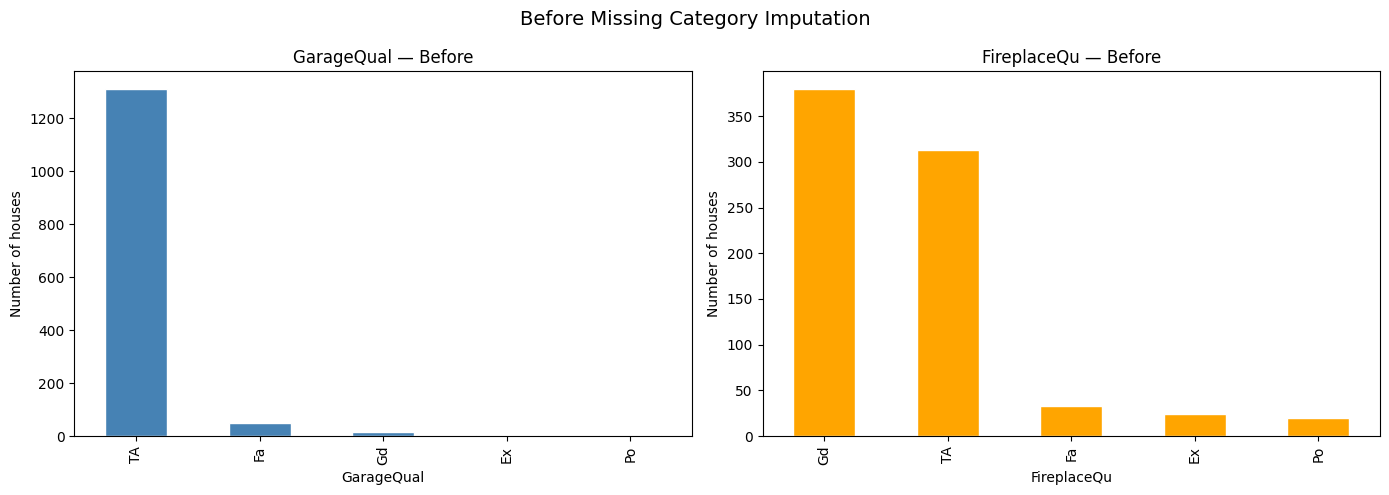

GarageQual unique categories: 5
FireplaceQu unique categories: 5

GarageQual value counts:
GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

FireplaceQu value counts:
FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Before Missing Category Imputation", fontsize=14)

# GarageQual distribution
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title("GarageQual — Before")
axes[0].set_xlabel("GarageQual")
axes[0].set_ylabel("Number of houses")

# FireplaceQu distribution
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[1], color='orange', edgecolor='white'
)
axes[1].set_title("FireplaceQu — Before")
axes[1].set_xlabel("FireplaceQu")
axes[1].set_ylabel("Number of houses")

plt.tight_layout()
plt.show()

print("GarageQual unique categories:", df['GarageQual'].nunique())
print("FireplaceQu unique categories:", df['FireplaceQu'].nunique())
print("\nGarageQual value counts:")
print(df['GarageQual'].value_counts())
print("\nFireplaceQu value counts:")
print(df['FireplaceQu'].value_counts())

### Apply Imputation Pandas Way

In [5]:
# Create a copy of the original dataframe
df_pandas = df.copy()

# Fill missing values
df_pandas['GarageQual'] = df_pandas['GarageQual'].fillna('Missing')
df_pandas['FireplaceQu'] = df_pandas['FireplaceQu'].fillna('Missing')

# Display results
print("After imputation:")

print("\nGarageQual value counts:")
print(df_pandas['GarageQual'].value_counts(dropna=False).sort_values(ascending=False))

print("\nFireplaceQu value counts:")
print(df_pandas['FireplaceQu'].value_counts(dropna=False).sort_values(ascending=False))

print("\nMissing values remaining:")
print(df_pandas[['GarageQual', 'FireplaceQu', 'SalePrice']].isnull().sum())

After imputation:

GarageQual value counts:
GarageQual
TA         1311
Missing      81
Fa           48
Gd           14
Ex            3
Po            3
Name: count, dtype: int64

FireplaceQu value counts:
FireplaceQu
Missing    690
Gd         380
TA         313
Fa          33
Ex          24
Po          20
Name: count, dtype: int64

Missing values remaining:
GarageQual     0
FireplaceQu    0
SalePrice      0
dtype: int64


### Visualize after Imputation

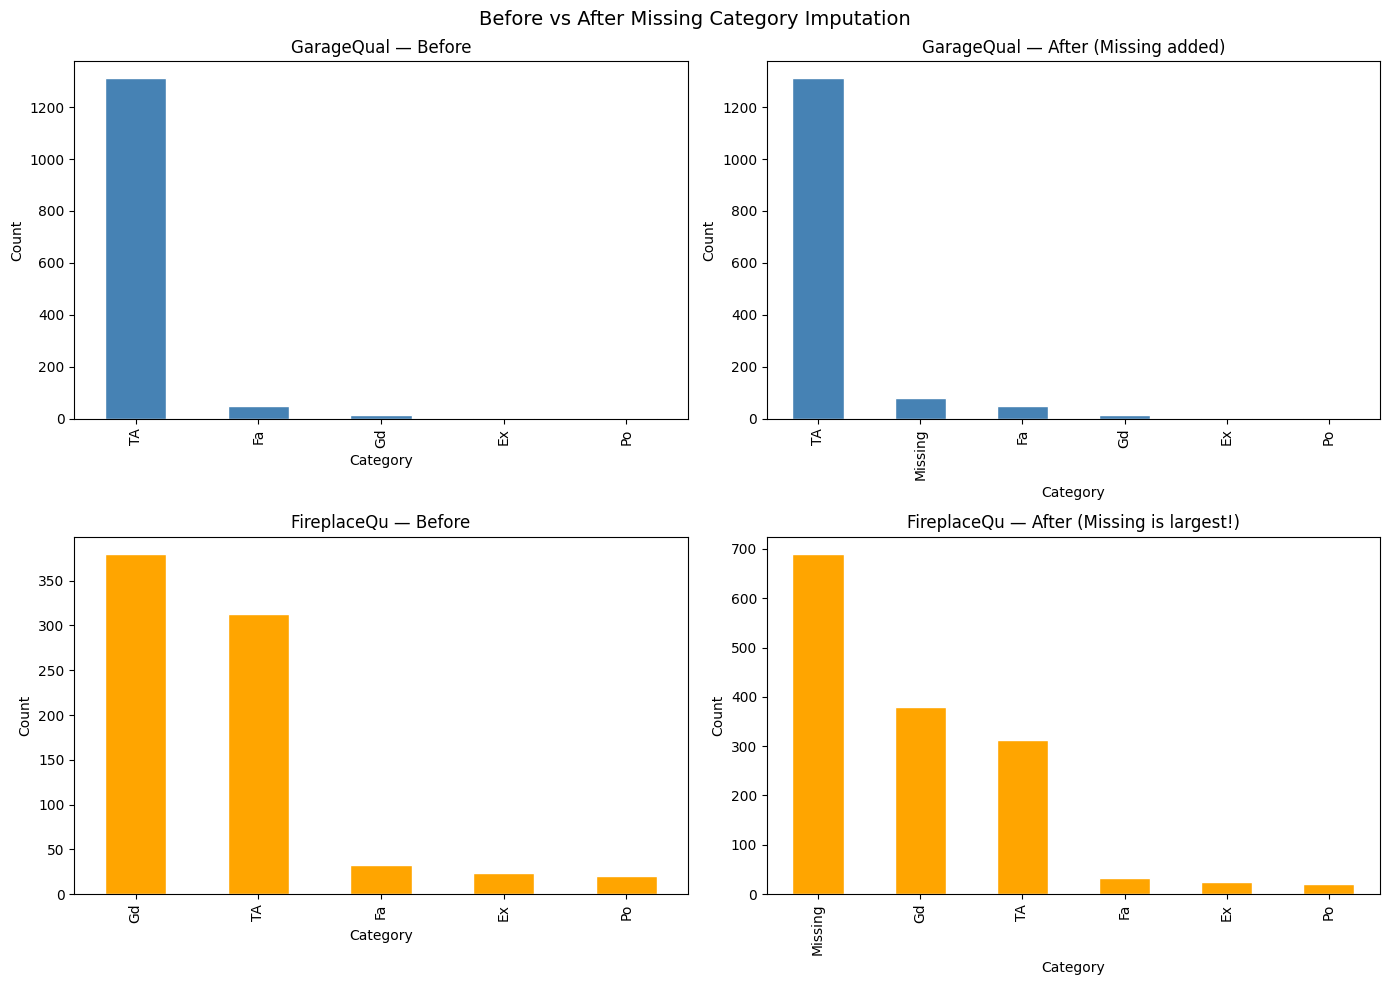

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Before vs After Missing Category Imputation", fontsize=14)

# GarageQual before
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[0][0], color='steelblue', edgecolor='white'
)
axes[0][0].set_title("GarageQual — Before")
axes[0][0].set_xlabel("Category")
axes[0][0].set_ylabel("Count")

# GarageQual after
df_pandas['GarageQual'].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[0][1], color='steelblue', edgecolor='white'
)
axes[0][1].set_title("GarageQual — After (Missing added)")
axes[0][1].set_xlabel("Category")
axes[0][1].set_ylabel("Count")

# FireplaceQu before
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[1][0], color='orange', edgecolor='white'
)
axes[1][0].set_title("FireplaceQu — Before")
axes[1][0].set_xlabel("Category")
axes[1][0].set_ylabel("Count")

# FireplaceQu after
df_pandas['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar(
    ax=axes[1][1], color='orange', edgecolor='white'
)
axes[1][1].set_title("FireplaceQu — After (Missing is largest!)")
axes[1][1].set_xlabel("Category")
axes[1][1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Train Test Split

In [7]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nMissing in X_train:")
print(X_train.isnull().sum())

print("\nMissing in X_test:")
print(X_test.isnull().sum())

X_train shape: (1168, 2)
X_test shape : (292, 2)

Missing in X_train:
FireplaceQu    547
GarageQual      64
dtype: int64

Missing in X_test:
FireplaceQu    143
GarageQual      17
dtype: int64


### Sklearn Way 

In [8]:
# SimpleImputer(strategy='constant', fill_value='Missing')
# strategy='constant' → fill with a fixed value
# fill_value='Missing' → that fixed value is the string "Missing"

imputer = SimpleImputer(
    strategy='constant',
    fill_value='Missing'
)

# fit on train only → learns that fill value is "Missing"
imputer.fit(X_train)

# see what it learned
print("Fill values learned:")
print(f"  GarageQual  → '{imputer.statistics_[0]}'")
print(f"  FireplaceQu → '{imputer.statistics_[1]}'")

# transform both train and test
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

print("\nX_train after imputation (first 5 rows):")
print(X_train_imp[:5])

print("\nMissing values remaining in train:", 
      pd.DataFrame(X_train_imp).isnull().sum().sum())
print("Missing values remaining in test :", 
      pd.DataFrame(X_test_imp).isnull().sum().sum())

Fill values learned:
  GarageQual  → 'Missing'
  FireplaceQu → 'Missing'

X_train after imputation (first 5 rows):
[['Missing' 'TA']
 ['TA' 'TA']
 ['Missing' 'Missing']
 ['TA' 'TA']
 ['Gd' 'TA']]

Missing values remaining in train: 0
Missing values remaining in test : 0


In [9]:
# convert to dataframe for easy analysis
X_train_df = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_test_df  = pd.DataFrame(X_test_imp,  columns=X_test.columns)

print("GarageQual distribution after imputation:")
print(X_train_df['GarageQual'].value_counts())

print("\nFireplaceQu distribution after imputation:")
print(X_train_df['FireplaceQu'].value_counts())

# check missing category % matches original missing %
garage_missing_pct   = (X_train_df['GarageQual'] == 'Missing').mean() * 100
fireplace_missing_pct = (X_train_df['FireplaceQu'] == 'Missing').mean() * 100

print(f"\nGarageQual 'Missing' %  : {garage_missing_pct:.1f}%")
print(f"FireplaceQu 'Missing' % : {fireplace_missing_pct:.1f}%")
print(f"\nOriginal missing %:")
print(f"  GarageQual  : {df['GarageQual'].isnull().mean()*100:.1f}%")
print(f"  FireplaceQu : {df['FireplaceQu'].isnull().mean()*100:.1f}%")

GarageQual distribution after imputation:
GarageQual
TA         1050
Missing      64
Fa           36
Gd           13
Ex            3
Po            2
Name: count, dtype: int64

FireplaceQu distribution after imputation:
FireplaceQu
Missing    547
Gd         305
TA         252
Fa          27
Ex          21
Po          16
Name: count, dtype: int64

GarageQual 'Missing' %  : 5.5%
FireplaceQu 'Missing' % : 46.8%

Original missing %:
  GarageQual  : 5.5%
  FireplaceQu : 47.3%


### Impact on Sale Price

In [11]:
# check if "Missing" category has different sale price
df_pandas = df.copy()
df_pandas['GarageQual'] = df_pandas['GarageQual'].fillna('Missing')
df_pandas['FireplaceQu'] = df_pandas['FireplaceQu'].fillna('Missing')

print("Mean SalePrice by GarageQual:")
print(df_pandas.groupby('GarageQual')['SalePrice']
      .mean().sort_values(ascending=False).round(0))

print("\nMean SalePrice by FireplaceQu:")
print(df_pandas.groupby('FireplaceQu')['SalePrice']
      .mean().sort_values(ascending=False).round(0))

Mean SalePrice by GarageQual:
GarageQual
Ex         241000.0
Gd         215861.0
TA         187490.0
Fa         123573.0
Missing    103317.0
Po         100167.0
Name: SalePrice, dtype: float64

Mean SalePrice by FireplaceQu:
FireplaceQu
Ex         337712.0
Gd         226351.0
TA         205723.0
Fa         167298.0
Missing    141331.0
Po         129764.0
Name: SalePrice, dtype: float64
